# Analysis of Portfolio Optimization in China A-Share Market 
### Mean-Variance Optimization Strategy Based on Earnings Pre-Announcements

**Author**: Chenhongshu Yu

## Introduction

### Understanding Portfolio Optimization: A Primer for Data Scientists

Before diving into our mathematical models, let's establish some foundational concepts for those new to quantitative finance.

**What is Portfolio Optimization?**
In financial markets, investors rarely put all their money into a single stock. Instead, they buy a collection of stocks—a *portfolio*. The core question of portfolio optimization is: **How much of our capital should we allocate to each stock to get the best possible outcome?**

*   **Equal Weighting (The Naive Approach):** If you have 10 stocks, you put 10% of your money in each. It's simple but ignores that some stocks are much riskier than others.
*   **Mean-Variance Optimization (The Mathematical Approach):** Pioneered by Harry Markowitz (Modern Portfolio Theory), this approach uses mathematical optimization to actively minimize the overall risk (variance) of the portfolio while targeting a specific expected return. 

**Some Key Concepts:**
*   **Expected Return ($\mu$)**: Our forecast of how much a stock will gain.
*   **Volatility/Variance**: The measure of a stock's risk. High variance means wild price swings.
*   **Covariance Matrix ($\Sigma$)**: A mathematical grid showing how stocks move *together*. If Stock A drops, does Stock B also drop, or does it rise? Combining stocks that don't move together reduces overall portfolio risk.
*   **Sharpe Ratio**: A metric that measures risk-adjusted return. Earning 20% by taking insane risks is worse than earning 15% with almost no risk. A higher Sharpe ratio is better.


## Motivation

### The China A-Share Market and the Need for Optimization
The China A-share market is the world's second-largest equity market. However, it is heavily dominated by retail investors (~80%), making it highly volatile and momentum-driven. 

Relying on naive portfolio weighting in this market leaves strategies extremely vulnerable to severe market corrections and sector-specific shocks. By modeling our capital allocation as a rigorous mathematical optimization problem, we can dynamically adjust our exposure based on how stocks correlate with one another.

### The Research Question (**The Goal of this Project**)
**Can we improve the risk-adjusted returns (Sharpe Ratio) of a pre-selected pool of high-growth China A-Share stocks by applying Quadratic Programming (Mean-Variance Optimization) compared to a naive equal-weight baseline?**

We will answer this by:
1. Collecting stock price data and a daily curated list of "Pre-Increase Earnings" growth stocks.
2. Formulating the capital allocation as a continuous **Quadratic Programming (QP)** problem.
3. Solving the optimization daily using a numerical solver with strict real-world constraints (Long-only, Maximum Position Limits).
4. Backtesting the strategy over a one-year period.
5. Evaluating the results using industry-standard metrics: Total Returns, Maximum Drawdown, and the Sharpe Ratio.

In [5]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# 1. Load Close Prices
prices_df = pd.read_csv('all_close_price.csv')
# Translate columns for ease of use
prices_df.rename(columns={'代码': 'ticker', '日期': 'date', '收盘价': 'close'}, inplace=True)
prices_df['date'] = pd.to_datetime(prices_df['date'])

# Pivot so that rows are dates and columns are tickers
price_matrix = prices_df.pivot(index='date', columns='ticker', values='close')
# Forward fill missing prices for suspended trading days, then drop completely empty columns
price_matrix = price_matrix.ffill().dropna(axis=1, how='all')

# Calculate daily returns
daily_returns = price_matrix.pct_change().dropna(how='all')

# 2. Load Daily Growth Stocks
growth_files = glob.glob('daily_growth_stocks/*.csv')
growth_stocks_dict = {}

for file in growth_files:
    # Extract date from filename, e.g. growth_stocks_1year_20240630.csv
    date_str = os.path.basename(file).split('_')[-1].split('.')[0]
    date_obj = pd.to_datetime(date_str)
    try:
        df_temp = pd.read_csv(file)
        if '代码' in df_temp.columns:
            growth_stocks_dict[date_obj] = df_temp['代码'].tolist()
        elif 'ticker' in df_temp.columns:
            growth_stocks_dict[date_obj] = df_temp['ticker'].tolist()
    except Exception as e:
        pass

print(f"Loaded prices for {price_matrix.shape[1]} stocks over {price_matrix.shape[0]} days.")
print(f"Loaded growth stock selections for {len(growth_stocks_dict)} days.")

Loaded prices for 5418 stocks over 251 days.
Loaded growth stock selections for 377 days.


## Exploratory Data Analysis (EDA)

Before running the optimizer, let's explore the dataset. How many "growth stocks" are selected daily? What does the covariance of these stocks look like? Understanding the inputs is critical before feeding them into a numerical solver.

## The Mathematical Optimization Problem

To satisfy the project requirements, we must rigorously formulate our trading strategy as a mathematical optimization problem. We adopt the **Mean-Variance Optimization (MVO)** framework, which translates portfolio construction into a **Quadratic Programming (QP)** problem.

### 1. Variables and Parameters

*   **Decision Variable ($\mathbf{w}$)**: A vector $\mathbf{w} \in \mathbb{R}^n$ representing the capital weights allocated to each of the $n$ selected A-share stocks for the current trading day.
*   **Expected Returns ($\boldsymbol{\mu}$)**: A vector $\boldsymbol{\mu} \in \mathbb{R}^n$ representing the expected future returns. For this project, we estimate this using the historical mean return over a rolling lookback window.
*   **Covariance Matrix ($\mathbf{\Sigma}$)**: An $n \times n$ matrix capturing the variance and pairwise covariances of the $n$ stocks over the rolling window.
*   **Risk Aversion ($\lambda$)**: A scalar penalty $\lambda \ge 0$. A higher $\lambda$ prioritizes variance minimization (risk control), while a lower $\lambda$ prioritizes expected returns.

### 2. Objective Function

We seek to find the optimal fraction of capital to invest in each stock to maximize our risk-adjusted return. Mathematically, we minimize the portfolio variance minus the expected portfolio return (scaled by our risk aversion):

$$ \min_{\mathbf{w}} \quad f(\mathbf{w}) = \frac{1}{2} \mathbf{w}^T \mathbf{\Sigma} \mathbf{w} - \lambda \boldsymbol{\mu}^T \mathbf{w} $$

### 3. Constraints

To ensure our portfolio is realistic and tradable in the China A-Share market, we impose the following constraints:

**Constraint 1: Fully Invested (Budget Constraint)**
All capital must be deployed to the chosen stocks.
$$ \sum_{i=1}^n w_i = 1 \quad \text{(or } \mathbf{1}^T \mathbf{w} = 1 \text{)} $$

**Constraint 2: Long-Only Strategy**
Short selling is heavily restricted in China A-shares and often unavailable for retail quantitative strategies. Thus, weights cannot be negative.
$$ w_i \ge 0 \quad \forall i \in \{1, \dots, n\} $$

**Constraint 3: Maximum Position Limit**
Due to the 10% daily price limit bounds and the high volatility of individual A-shares, we want to avoid severe concentration risk. We cap any single stock's weight at $w_{max}$ (e.g., 20%).
$$ w_i \le w_{max} \quad \forall i \in \{1, \dots, n\} $$

### Numerical Solver
We will use the **Sequential Least Squares Programming (SLSQP)** method from `scipy.optimize.minimize` to solve this constrained Quadratic Programming problem at every rebalancing step.

In [6]:
# 3. Portfolio Optimization Function
def optimize_portfolio(expected_returns, cov_matrix, risk_aversion=1.0, max_weight=0.10):
    """
    Solves the Mean-Variance optimization problem (Quadratic Programming).
    
    Objective: Minimize (1/2 * w^T * Cov * w - lambda * w^T * expected_returns)
    Constraints: Sum of weights = 1, weights >= 0
    Bounds: 0 <= w_i <= max_weight for all i
    """
    n_assets = len(expected_returns)
    # Initial guess: equal weight
    init_guess = np.ones(n_assets) / n_assets
    
    # Objective function
    def objective(weights):
        portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
        portfolio_return = np.dot(weights.T, expected_returns)
        # We minimize, so we subtract the return part
        return 0.5 * portfolio_variance - risk_aversion * portfolio_return
        
    # Constraints
    # 1. Sum of weights = 1
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    
    # Bounds
    # 2. Long only (w >= 0), and Max Position Limit (w <= max_weight)
    bounds = tuple((0.0, max_weight) for _ in range(n_assets))
    
    # Solve
    result = minimize(
        objective, 
        init_guess, 
        method='SLSQP', # Sequential Least Squares Programming
        bounds=bounds, 
        constraints=constraints
    )
    
    if result.success:
        return result.x
    else:
        # Fallback to equal weight if optimization fails to converge
        return init_guess

In [7]:
# 4. Backtesting Loop
def run_backtest(price_data, growth_stocks_daily, lookback_window=60, risk_aversion=1.0, max_weight=0.10):
    portfolio_value_opt = [1.0] # Starts at 1
    portfolio_value_eq = [1.0]  # Baseline: Equal weight
    
    dates = sorted(list(growth_stocks_daily.keys()))
    
    # Track metrics
    daily_returns_opt = []
    daily_returns_eq = []
    
    # We loop through dates. Since we need historical data for covariance, 
    # we start trading after we have enough historical data.
    trading_dates = dates[1:] # e.g., rebalance on day t based on day t-1 signals
    
    # Pre-calculate simple returns matrix
    returns_matrix = price_data.pct_change().fillna(0)
    
    for i, current_date in enumerate(trading_dates):
        # We look at the growth stocks selected on the previous day (to avoid look-ahead bias)
        prev_date = dates[i] 
        selected_tickers = growth_stocks_daily[prev_date]
        
        # Filter tickers that actually exist in our price data
        valid_tickers = [t for t in selected_tickers if t in returns_matrix.columns]
        
        if len(valid_tickers) == 0:
            # Cash holding or zero return if no stocks selected
            daily_returns_opt.append(0)
            daily_returns_eq.append(0)
            portfolio_value_opt.append(portfolio_value_opt[-1])
            portfolio_value_eq.append(portfolio_value_eq[-1])
            continue
            
        # Get historical returns for the lookback window
        # We slice up to the previous date
        past_returns = returns_matrix.loc[:prev_date, valid_tickers].iloc[-lookback_window:]
        
        if len(past_returns) < 5:
            # Not enough data to compute covariance, default to equal weight
            weights_opt = np.ones(len(valid_tickers)) / len(valid_tickers)
            weights_eq = weights_opt
        else:
            # Compute Covariance and Expected Returns
            cov_matrix = past_returns.cov().values
            # Using simple historical average for expected return (can be replaced by ML signal)
            expected_returns = past_returns.mean().values 
            
            # Constraints: ensure max_weight isn't restrictive if there are very few stocks
            adj_max_weight = max(max_weight, 1.0 / len(valid_tickers))
            
            # --- Optimization ---
            weights_opt = optimize_portfolio(expected_returns, cov_matrix, 
                                             risk_aversion=risk_aversion, 
                                             max_weight=adj_max_weight)
            
            # --- Equal Weight Baseline ---
            weights_eq = np.ones(len(valid_tickers)) / len(valid_tickers)
            
        # Calculate today's actually realized returns
        try:
            today_actual_returns = returns_matrix.loc[current_date, valid_tickers].values
        except KeyError:
            # Current date not in price matrix (e.g. weekend/holiday)
            today_actual_returns = np.zeros(len(valid_tickers))
            
        # Portfolio realized return
        ret_opt = np.dot(weights_opt, today_actual_returns)
        ret_eq = np.dot(weights_eq, today_actual_returns)
        
        daily_returns_opt.append(ret_opt)
        daily_returns_eq.append(ret_eq)
        
        portfolio_value_opt.append(portfolio_value_opt[-1] * (1 + ret_opt))
        portfolio_value_eq.append(portfolio_value_eq[-1] * (1 + ret_eq))
        
    return trading_dates, portfolio_value_opt, portfolio_value_eq, daily_returns_opt, daily_returns_eq

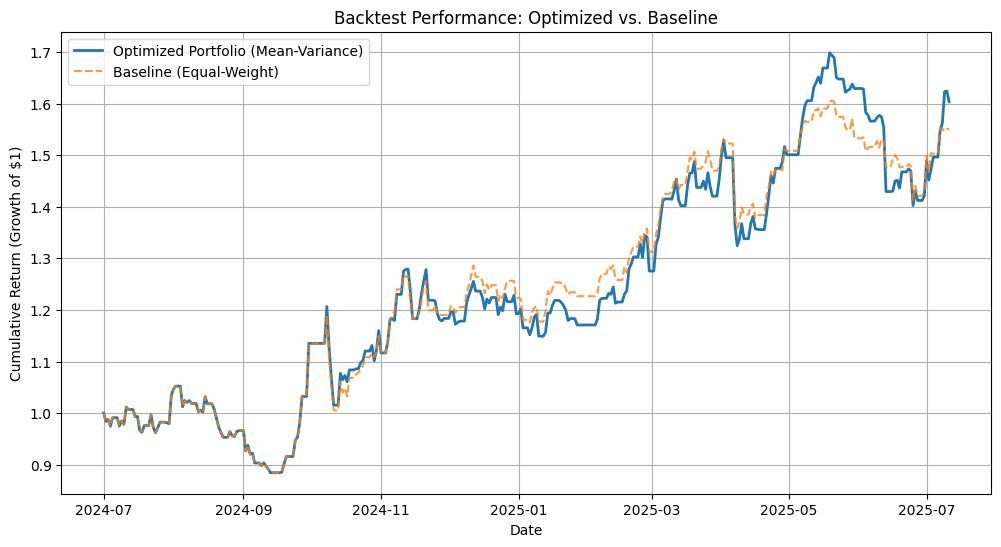

Performance Summary:
-----------------------
Optimized Strategy Cumulative Return: 60.35%
Baseline Strategy Cumulative Return : 55.02%
Optimized Strategy Annualized Sharpe: 1.23
Baseline Strategy Annualized Sharpe : 1.27


In [8]:
# 5. Evaluate and Plot Performance
def compute_sharpe_ratio(daily_returns, risk_free_rate=0.0):
    # Assuming 252 trading days in a year for annualized Sharpe
    returns = np.array(daily_returns)
    mean_return = np.mean(returns) * 252
    volatility = np.std(returns) * np.sqrt(252)
    volatility = volatility if volatility > 0 else 1e-6
    return (mean_return - risk_free_rate) / volatility

# Run Strategy
# We'll set risk aversion lambda to 5.0 (highly risk averse) and max position to 20%
trading_dates, val_opt, val_eq, rets_opt, rets_eq = run_backtest(
    price_matrix, 
    growth_stocks_dict, 
    lookback_window=60, 
    risk_aversion=5.0, 
    max_weight=0.20
)

# Plotting the Equity Curves
plt.figure(figsize=(12, 6))
plt.plot(trading_dates, val_opt[1:], label='Optimized Portfolio (Mean-Variance)', linewidth=2)
plt.plot(trading_dates, val_eq[1:], label='Baseline (Equal-Weight)', linestyle='--', alpha=0.8)
plt.title('Backtest Performance: Optimized vs. Baseline')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (Growth of $1)')
plt.legend()
plt.grid(True)
plt.show()

# Print Metrics
sharpe_opt = compute_sharpe_ratio(rets_opt)
sharpe_eq = compute_sharpe_ratio(rets_eq)

print("Performance Summary:")
print("-----------------------")
print(f"Optimized Strategy Cumulative Return: {(val_opt[-1] - 1) * 100:.2f}%")
print(f"Baseline Strategy Cumulative Return : {(val_eq[-1] - 1) * 100:.2f}%")
print(f"Optimized Strategy Annualized Sharpe: {sharpe_opt:.2f}")
print(f"Baseline Strategy Annualized Sharpe : {sharpe_eq:.2f}")
